In [130]:
#importing necessary libraries
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt
import pandas as pd

In [173]:
#importing emg signals from file
#EMG data
file_path = 'Total data\Excel Sheets\Amresh Kumar MVC_Right_5RR_3.xlsx'
# Skip the first 9 rows, assuming EMG starts from row 10 (index 9)
df = pd.read_excel(file_path, skiprows=9, engine='openpyxl')
#dropping unnecessary data
df_clean = df.iloc[:, [0, 2, 3, 4, 5, 6, 7]]
#showing the data
print(df_clean.head())

    3.995000   0.240969  -0.032656   0.008766  -0.010141   0.040219   0.027328
0     3.9955   0.168266  -0.004812   0.006359  -0.011859   0.091609   0.029391
1     3.9960   0.055516   0.024922   0.004125  -0.011516   0.128391   0.032484
2     3.9965  -0.016500   0.049156   0.001891  -0.012203   0.145578   0.028703
3     3.9970  -0.045031   0.064453   0.001031  -0.012891   0.146953   0.028188
4     3.9975  -0.035922   0.074938   0.002750  -0.013406   0.138703   0.032141


In [174]:
#renaming columns for clarity
df_clean.columns = ['Time', 'Muscle1', 'Muscle2', 'Muscle3', 'Muscle4', 'Muscle5', 'Muscle6']
# Extract time and EMG
time = df_clean['Time'].values
emg_signals = df_clean.iloc[:, 1:].values  # shape: (samples, 6)


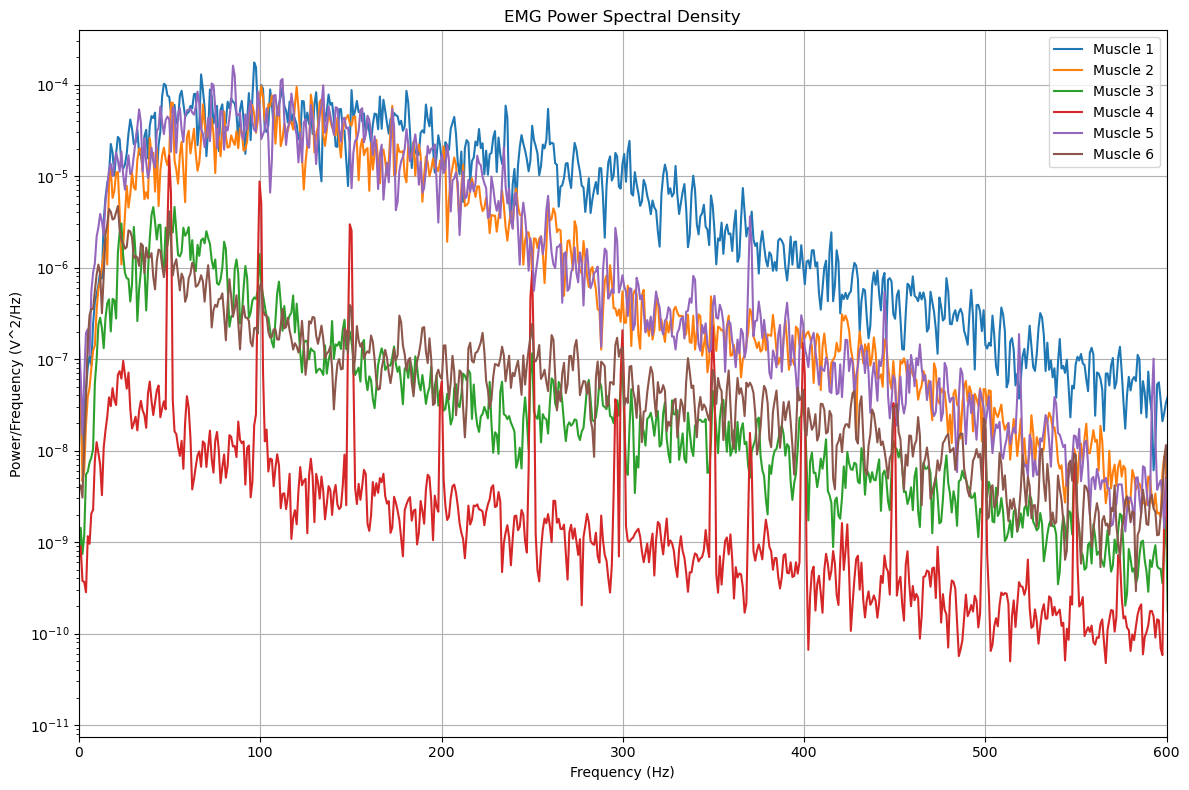

In [175]:
#powe spectral density calculation for defining frequency bands
#sampling frequency
fs = 2000  # Hz
plt.figure(figsize=(12, 8))
for i in range(6):
    freqs, psd = welch(emg_signals[:, i], fs=fs, nperseg=2048)
    plt.semilogy(freqs, psd, label=f'Muscle {i+1}')

plt.title('EMG Power Spectral Density')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Frequency (V^2/Hz)')
plt.xlim(0, 600)  # to zoom in on the relevant frequencies
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [176]:
nperseg = 2048
for i in range(6):
   freqs, psd = welch(emg_signals[:, i], fs=fs, nperseg=nperseg)
   
   peak_idx = np.argmax(psd)
   peak_freq = freqs[peak_idx]
   
   # Threshold at 10% of peak to find band range
   threshold = 0.1 * psd[peak_idx]
   active_band = freqs[psd >= threshold]
   if len(active_band) > 0:
       band_min = active_band[0]
       band_max = active_band[-1]
   else:
       band_min = band_max = None
   # Power at 50 Hz
   idx_50 = np.argmin(np.abs(freqs - 50))
   power_50hz = psd[idx_50]
   print(f"Muscle {i+1}:")
   print(f"  ➤ Peak Power Frequency: {peak_freq:.2f} Hz")
   if band_min and band_max:
       print(f"  ➤ Power Spread (10% of peak): {band_min:.2f} – {band_max:.2f} Hz")
   print(f"  ➤ Power at 50 Hz (Notch Target): {power_50hz:.2e}\n")


Muscle 1:
  ➤ Peak Power Frequency: 96.68 Hz
  ➤ Power Spread (10% of peak): 17.58 – 303.71 Hz
  ➤ Power at 50 Hz (Notch Target): 7.36e-05

Muscle 2:
  ➤ Peak Power Frequency: 100.59 Hz
  ➤ Power Spread (10% of peak): 17.58 – 211.91 Hz
  ➤ Power at 50 Hz (Notch Target): 1.74e-05

Muscle 3:
  ➤ Peak Power Frequency: 52.73 Hz
  ➤ Power Spread (10% of peak): 21.48 – 118.16 Hz
  ➤ Power at 50 Hz (Notch Target): 2.54e-06

Muscle 4:
  ➤ Peak Power Frequency: 49.80 Hz
  ➤ Power Spread (10% of peak): 48.83 – 150.39 Hz
  ➤ Power at 50 Hz (Notch Target): 1.68e-05

Muscle 5:
  ➤ Peak Power Frequency: 84.96 Hz
  ➤ Power Spread (10% of peak): 20.51 – 234.38 Hz
  ➤ Power at 50 Hz (Notch Target): 4.17e-05

Muscle 6:
  ➤ Peak Power Frequency: 21.48 Hz
  ➤ Power Spread (10% of peak): 8.79 – 100.59 Hz
  ➤ Power at 50 Hz (Notch Target): 4.12e-06



In [177]:
#Data filtering
from scipy.signal import butter, filtfilt, iirnotch
import numpy as np

# --- Parameters ---
fs = 2000  # Sampling frequency (Hz)
lowcut = 20
highcut = 170
notch_freq = 50
notch_Q = 30  # Quality factor for narrowband notch
# --- Bandpass filter design ---
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)
#--- Notch filter design ---
def notch_filter(data, freq, fs, Q=30):
    nyq = 0.5 * fs
    w0 = freq / nyq
    b, a = iirnotch(w0, Q)
    return filtfilt(b, a, data)
#--- Apply both filters ---
filtered_emg = []
for i in range(emg_signals.shape[1]):
    raw = emg_signals[:, i]
    bandpassed = bandpass_filter(raw, lowcut, highcut, fs)
    cleaned = notch_filter(bandpassed, notch_freq, fs, notch_Q)
    filtered_emg.append(cleaned)

filtered_emg = np.array(filtered_emg).T  # shape: (samples, muscles)

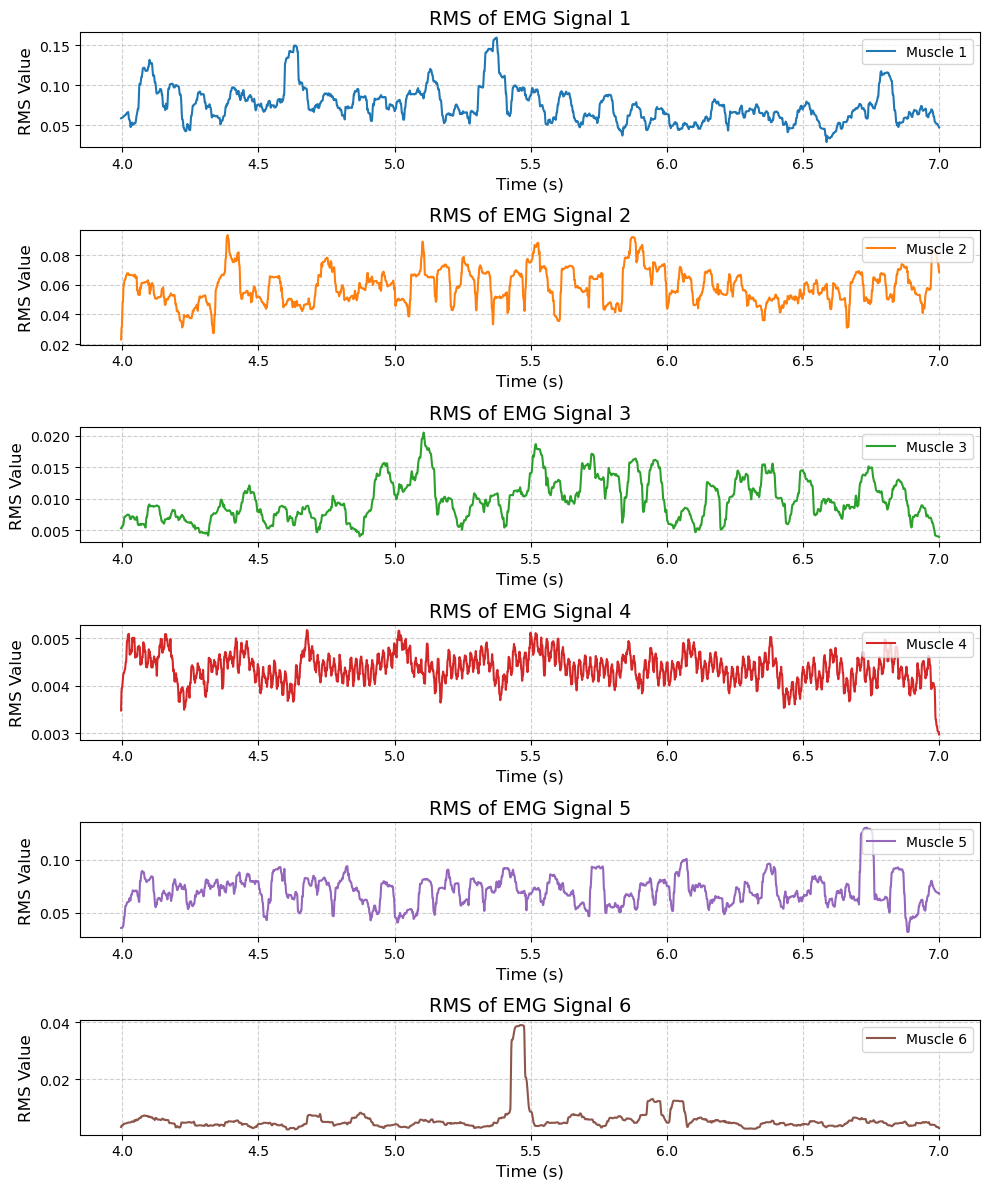

In [181]:
# Set RMS window size (in samples)
window_size = int(0.05 * fs)  # 50ms window for RMS calculation, based on 2000 Hz sampling rate

# Function to calculate RMS for each EMG signal
def calculate_rms(emg_signal, window_size):
    rms = np.sqrt(np.convolve(emg_signal**2, np.ones(window_size)/window_size, mode='same'))
    return rms

# Rectify and calculate RMS for each EMG signal
rms_emg = []
for i in range(filtered_emg.shape[1]):
    # Rectification
    rectified_signal = np.abs(filtered_emg[:, i])
    
    # Calculate RMS
    rms_signal = calculate_rms(rectified_signal, window_size)
    rms_emg.append(rms_signal)

rms_emg = np.array(rms_emg).T  # Shape: (samples, muscles)

# Create separate plots for each muscle signal's RMS
num_signals = rms_emg.shape[1]
fig, axes = plt.subplots(num_signals, 1, figsize=(10, 2 * num_signals))

# Iterate through each muscle and plot its RMS signal
for i in range(num_signals):
    ax = axes[i]
    ax.plot(time, rms_emg[:, i], label=f'Muscle {i+1}', color=f'C{i}')
    ax.set_title(f'RMS of EMG Signal {i+1}', fontsize=14)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('RMS Value', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper right', fontsize=10)
    
# Improve layout
plt.tight_layout()

# Show the plots
plt.show()


In [179]:
 # Save the RMS data to a .csv file with time as the first column
rms_df = pd.DataFrame(rms_emg)
rms_df.insert(0, 'Time', time)  # Add time as the first column

# Save to CSV
rms_df.to_csv('amreshkumarright3.csv', index=False)

print("RMS data saved to 'filtered_rms_emg_with_time.csv'")

RMS data saved to 'filtered_rms_emg_with_time.csv'
